# F1 Pit Stop Prediction — Training Framework

Binary classification: predict `PitNextLap` (whether the driver pits on the next lap).

Pipeline: load → EDA → preprocess → CV training → submission.

EDA lives in `eda.ipynb`. This notebook covers feature engineering, cross-validated training, and submission.

In [1]:
# =============================================================
# AUTO-INSTALL + IMPORTS
# =============================================================

import sys
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "lightgbm",
    "xgboost",
    "catboost",
    "scipy"
]

for package in REQUIRED_PACKAGES:
    try:
        __import__(package.replace("-", "_"))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package]
        )

# =============================================================
# IMPORTS
# =============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

from scipy.stats import rankdata

# =============================================================
# SETTINGS
# =============================================================

pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42

DATA_DIR = Path('.')

print("All libraries imported successfully.")

/home/propar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Installing scikit-learn...
Defaulting to user installation because normal site-packages is not writeable
Installing xgboost...
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 10.3 MB/s eta 0:00:00
Installing catboost...
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 KB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.9/451.9 KB 6.4 MB/s eta 0:00:00
All libraries imported successfully.


## 1. Load data

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'PitNextLap'
ID_COL = 'id'

print('train:', train.shape, '| test:', test.shape)
train.head()

train: (439140, 16) | test: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Feature engineering

In [3]:
# =============================================================
# IMPORTS
# =============================================================

import numpy as np
import pandas as pd

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

from scipy.stats import rankdata

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)

# =============================================================
# FEATURE ENGINEERING
# =============================================================

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Improved feature engineering for F1 pit-stop prediction.

    Philosophy:
    - Remove redundant/raw overlapping variables
    - Add interaction-based strategic features
    - Add nonlinear race-window behaviour
    - Preserve primitive variables for tree models
    - Avoid unstable exploding ratios
    """

    df = df.copy()

    # =========================================================
    # BASIC SAFE VARIABLES
    # =========================================================

    eps = 1e-6

    # Remaining race fraction
    df['RemainingRace'] = 1.0 - df['RaceProgress']

    # Mid-race pit-window tendency
    df['PitWindow'] = (
        df['RaceProgress'] *
        (1 - df['RaceProgress'])
    )

    # Late race binary
    df['IsLateRace'] = (
        df['RaceProgress'] > 0.7
    ).astype(int)

    # =========================================================
    # TYRE DYNAMICS
    # =========================================================

    # Pace per tyre age
    df['LapTime_per_TyreLife'] = (
        df['LapTime (s)'] /
        (df['TyreLife'] + eps)
    )

    # Degradation rate per lap
    df['Deg_per_TyreLife'] = (
        df['Cumulative_Degradation'] /
        (df['TyreLife'] + eps)
    )

    # Total tyre stress
    df['TyreStress'] = (
        df['TyreLife'] *
        df['Cumulative_Degradation']
    )

    # Strategic urgency
    df['StrategicUrgency'] = (
        df['TyreLife'] *
        df['Cumulative_Degradation'] *
        df['RemainingRace']
    )

    # Tyre exhaustion factor
    df['TyreExhaustion'] = (
        (df['TyreLife'] ** 2) *
        df['RemainingRace']
    )

    # Tyre cliff detector
    df['TyreCliff'] = (
        df['TyreLife'] *
        df['LapTime_Delta']
    )

    # =========================================================
    # STRATEGY / POSITION FEATURES
    # =========================================================

    # Position pressure
    df['PositionPressure'] = (
        df['Position'] *
        df['RemainingRace']
    )

    # Recovery pressure
    df['RecoveryPressure'] = (
        abs(df['Position_Change']) *
        df['Cumulative_Degradation']
    )

    # =========================================================
    # COMPOUND FEATURES
    # =========================================================

    compound_map = {
        'HARD': 1,
        'MEDIUM': 2,
        'SOFT': 3
    }

    df['CompoundCode'] = (
        df['Compound']
        .astype(str)
        .str.upper()
        .map(compound_map)
        .fillna(2)
    )

    df['CompoundTyreInteraction'] = (
        df['CompoundCode'] *
        df['TyreLife']
    )

    # =========================================================
    # STRATEGIC PIT PRESSURE
    # =========================================================

    df['StrategyPressure'] = (
        df['TyreStress'] *
        df['PitWindow']
    )

    # =========================================================
    # REALISTIC F1 PIT-STOP THINKING
    # =========================================================

    # Can tyre pace loss offset pit-stop cost?
    # Captures whether staying out is becoming expensive
    df['PitOffsetPotential'] = (
        df['LapTime_Delta'] *
        df['RemainingRace'] *
        10
    )

    # Aggressive undercut opportunity
    df['UndercutPotential'] = (
        df['LapTime_Delta'] *
        abs(df['Position_Change']) *
        df['RemainingRace']
    )

    # Race-ending tyre survival pressure
    df['StintSurvivalPressure'] = (
        df['TyreLife'] *
        df['RemainingRace'] *
        df['LapTime_Delta']
    )

    # Pace collapse detector
    df['PaceCollapse'] = (
        df['LapTime_Delta'] *
        df['Cumulative_Degradation']
    )

    # High tyre age late in race
    df['LateRaceTyreRisk'] = (
        df['IsLateRace'] *
        df['TyreLife']
    )

    return df


# =============================================================
# APPLY FEATURE ENGINEERING
# =============================================================

train_fe = add_features(train)
test_fe  = add_features(test)

# =============================================================
# CATEGORICAL FEATURES
# =============================================================

CAT_COLS = [
    'Driver',
    'Compound',
    'Race'
]

for c in CAT_COLS:
    train_fe[c] = train_fe[c].astype('category')
    test_fe[c]  = test_fe[c].astype('category')

# =============================================================
# DROP COLUMNS
# =============================================================

DROP_COLS = [
    ID_COL,
    TARGET,
    'LapNumber',
]

# =============================================================
# FINAL FEATURE LIST
# =============================================================

FEATURES = [
    c for c in train_fe.columns
    if c not in DROP_COLS
]

print(f'{len(FEATURES)} features')
print(FEATURES)

# =============================================================


32 features
['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'RemainingRace', 'PitWindow', 'IsLateRace', 'LapTime_per_TyreLife', 'Deg_per_TyreLife', 'TyreStress', 'StrategicUrgency', 'TyreExhaustion', 'TyreCliff', 'PositionPressure', 'RecoveryPressure', 'CompoundCode', 'CompoundTyreInteraction', 'StrategyPressure', 'PitOffsetPotential', 'UndercutPotential', 'StintSurvivalPressure', 'PaceCollapse', 'LateRaceTyreRisk']


## 4. Cross-validation training

Group by `(Race, Year, Driver)` so the same stint doesn't leak across folds.

In [4]:
# DATA
# =============================================================

X = train_fe.drop(
    columns=[c for c in DROP_COLS if c in train_fe.columns]
)

y = train_fe[TARGET]

groups = (
    train_fe['Race'].astype(str) + '_' +
    train_fe['Year'].astype(str) + '_' +
    train_fe['Driver'].astype(str)
)

X_test = test_fe.drop(
    columns=[c for c in DROP_COLS if c in test_fe.columns]
)

# =============================================================
# LIGHTGBM PARAMS
# =============================================================

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': 42,
    'num_threads': 8,
    'force_row_wise': True,
}

# =============================================================
# XGBOOST PARAMS
# =============================================================

xgb_params = {
    'n_estimators': 3000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'min_child_weight': 50,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'seed': 42,
    'tree_method': 'hist',
    'early_stopping_rounds': 100,
}

# =============================================================
# CATBOOST PARAMS
# =============================================================

cb_params = {
    'iterations': 3000,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'verbose': 200,
}

# =============================================================
# RANK AVERAGING
# =============================================================

def rank_avg(*preds):

    n = len(preds[0])

    return (
        sum(rankdata(p) / n for p in preds)
        / len(preds)
    )

# =============================================================
# CROSS VALIDATION
# =============================================================

N_SPLITS = 5

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

# =============================================================
# OOF STORAGE
# =============================================================

oof_lgb = np.zeros(len(train_fe))
oof_xgb = np.zeros(len(train_fe))
oof_cb  = np.zeros(len(train_fe))

test_lgb = np.zeros(len(test_fe))
test_xgb = np.zeros(len(test_fe))
test_cb  = np.zeros(len(test_fe))

feat_importance = pd.DataFrame(index=FEATURES)

# =============================================================
# TRAINING LOOP
# =============================================================

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):

    print(f'\n================ FOLD {fold} ================\n')

    X_tr = X.iloc[tr_idx][FEATURES]
    X_va = X.iloc[va_idx][FEATURES]

    y_tr = y.iloc[tr_idx]
    y_va = y.iloc[va_idx]

    X_te_f = X_test[FEATURES]

    # =========================================================
    # LIGHTGBM
    # =========================================================

    dtr = lgb.Dataset(
        X_tr,
        y_tr,
        categorical_feature=CAT_COLS
    )

    dva = lgb.Dataset(
        X_va,
        y_va,
        categorical_feature=CAT_COLS
    )

    lgb_model = lgb.train(
        lgb_params,
        dtr,
        num_boost_round=3000,
        valid_sets=[dva],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(200)
        ],
    )

    oof_lgb[va_idx] = lgb_model.predict(X_va)

    test_lgb += (
        lgb_model.predict(X_te_f)
        / N_SPLITS
    )

    feat_importance[f'fold{fold}'] = (
        lgb_model.feature_importance(
            importance_type='gain'
        )
    )

    # =========================================================
    # XGBOOST
    # =========================================================

    X_tr_xgb = X_tr.copy()
    X_va_xgb = X_va.copy()
    X_te_xgb = X_te_f.copy()

    for c in CAT_COLS:
        X_tr_xgb[c] = X_tr_xgb[c].cat.codes
        X_va_xgb[c] = X_va_xgb[c].cat.codes
        X_te_xgb[c] = X_te_xgb[c].cat.codes

    xgb_model = xgb.XGBClassifier(**xgb_params)

    xgb_model.fit(
        X_tr_xgb,
        y_tr,
        eval_set=[(X_va_xgb, y_va)],
        verbose=200
    )

    oof_xgb[va_idx] = (
        xgb_model.predict_proba(X_va_xgb)[:, 1]
    )

    test_xgb += (
        xgb_model.predict_proba(X_te_xgb)[:, 1]
        / N_SPLITS
    )

    # =========================================================
    # CATBOOST
    # =========================================================

    cat_features_idx = [
        X_tr.columns.get_loc(col)
        for col in CAT_COLS
    ]

    cb_model = cb.CatBoostClassifier(**cb_params)

    cb_model.fit(
        X_tr,
        y_tr,
        eval_set=(X_va, y_va),
        cat_features=cat_features_idx,
        verbose=200
    )

    oof_cb[va_idx] = (
        cb_model.predict_proba(X_va)[:, 1]
    )

    test_cb += (
        cb_model.predict_proba(X_te_f)[:, 1]
        / N_SPLITS
    )

    # =========================================================
    # FOLD METRICS
    # =========================================================

    fold_lgb_auc = roc_auc_score(
        y_va,
        oof_lgb[va_idx]
    )

    fold_xgb_auc = roc_auc_score(
        y_va,
        oof_xgb[va_idx]
    )

    fold_cb_auc = roc_auc_score(
        y_va,
        oof_cb[va_idx]
    )

    print(f'LGB Fold AUC : {fold_lgb_auc:.5f}')
    print(f'XGB Fold AUC : {fold_xgb_auc:.5f}')
    print(f'CAT Fold AUC : {fold_cb_auc:.5f}')

# =============================================================
# ENSEMBLE
# =============================================================

oof_ensemble = rank_avg(
    oof_lgb,
    oof_xgb,
    oof_cb
)

test_ensemble = rank_avg(
    test_lgb,
    test_xgb,
    test_cb
)

# =============================================================
# FINAL METRICS
# =============================================================

print('\n================ FINAL RESULTS ================\n')

print('ENSEMBLE OOF AUC :',
      roc_auc_score(y, oof_ensemble))

print('ENSEMBLE OOF AP  :',
      average_precision_score(y, oof_ensemble))

print('ENSEMBLE OOF LL  :',
      log_loss(y, oof_ensemble))

# =============================================================
# FEATURE IMPORTANCE
# =============================================================

feat_importance['mean_gain'] = (
    feat_importance.mean(axis=1)
)

feat_importance = feat_importance.sort_values(
    'mean_gain',
    ascending=False
)

print('\nTop Features:')
print(feat_importance.head(20))

# =============================================================
# SUBMISSION
# =============================================================

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: test_ensemble
})

submission.to_csv(
    'submission.csv',
    index=False
)

print('\nsubmission.csv saved')


================ FOLD 0 ================

Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941793
[400]	valid_0's auc: 0.942027
[600]	valid_0's auc: 0.942451
[800]	valid_0's auc: 0.942722
Early stopping, best iteration is:
[779]	valid_0's auc: 0.942769
[0]	validation_0-auc:0.91626
[200]	validation_0-auc:0.94232
[400]	validation_0-auc:0.94513
[600]	validation_0-auc:0.94630
[800]	validation_0-auc:0.94696
[1000]	validation_0-auc:0.94733
[1200]	validation_0-auc:0.94763
[1400]	validation_0-auc:0.94780
[1600]	validation_0-auc:0.94798
[1800]	validation_0-auc:0.94809
[1974]	validation_0-auc:0.94811
0:	test: 0.9009071	best: 0.9009071 (0)	total: 118ms	remaining: 5m 55s
200:	test: 0.9380389	best: 0.9380389 (200)	total: 9.3s	remaining: 2m 9s
400:	test: 0.9420706	best: 0.9420706 (400)	total: 18.1s	remaining: 1m 57s
600:	test: 0.9437799	best: 0.9437799 (600)	total: 27.2s	remaining: 1m 48s
800:	test: 0.9448892	best: 0.9448892 (800)	total: 36.5s	remaining: 1m 40s
1

## 5. Feature importance

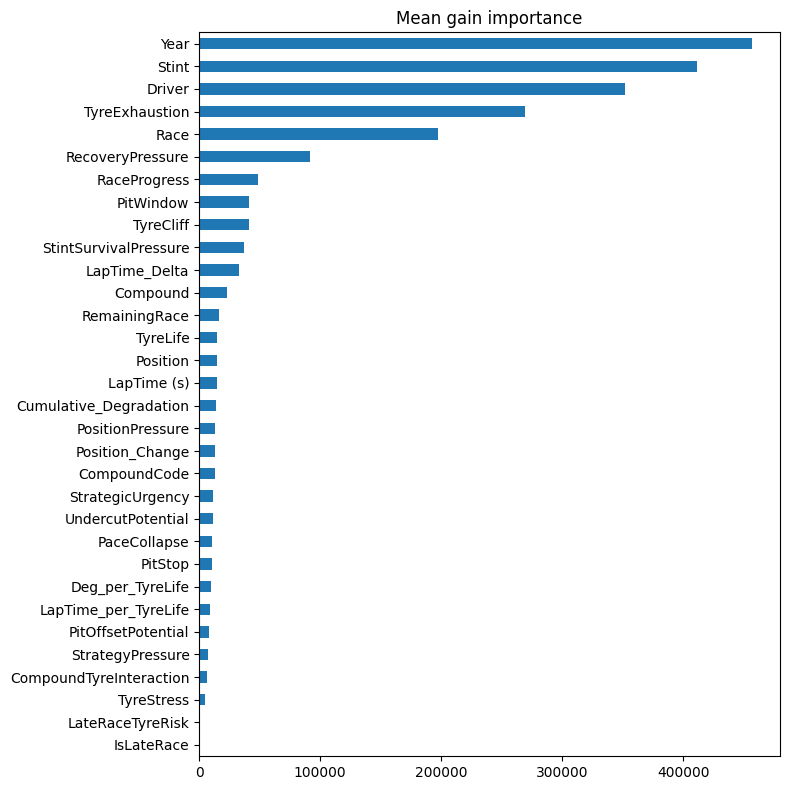

In [5]:
imp = feat_importance.mean(axis=1).sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(imp) * 0.25))); imp.plot.barh(); plt.title('Mean gain importance'); plt.tight_layout(); plt.show()

## 6. Submission

In [ ]:
submission = sample_submission.copy()
submission[TARGET] = test_ensemble
submission.to_csv('submission.csv', index=False)
submission.head()